# Gerekli Kütüphanelerin İçeri Aktarılması

In [ ]:
from scipy.io import arff
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.tree import plot_tree

# Veriyi İçeri Aktarma

In [ ]:

# Dosya yolunu verme
dosya_yolu = 'Training Dataset.arff'

# ARFF dosyasını yükleme
veri, meta_veri = arff.loadarff(dosya_yolu)

# Okunan veriyi Pandas DataFrame formatına çevirme
df = pd.DataFrame(veri)

# ARFF formatından okunan kategorik/string veriler genellikle byte (örn: b'1', b'-1') olarak gelir.
# Modeli eğitmeden önce bu verileri standart string veya integer formatına dönüştürmek temiz bir adım olacaktır:
kategorik_sutunlar = df.select_dtypes(include=['object']).columns
for sutun in kategorik_sutunlar:

    df[sutun] = df[sutun].str.decode('utf-8')




# Veri Hakkındaki Bilgilerin Detayları (EDA)

In [ ]:
df.head() #Verinin ilk 5 satırını gösterme

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [ ]:
df.describe().T #Verinin istatistiksel özetini gösterme

,count,unique,top,freq
having_IP_Address,11055,2,1,7262
URL_Length,11055,3,-1,8960
Shortining_Service,11055,2,1,9611
having_At_Symbol,11055,2,1,9400
double_slash_redirecting,11055,2,1,9626
Prefix_Suffix,11055,2,-1,9590
having_Sub_Domain,11055,3,1,4070
SSLfinal_State,11055,3,1,6331
Domain_registeration_length,11055,2,-1,7389
Favicon,11055,2,1,9002


# Hedef Değişkeninin Dağılımı

Eksik değer sayısı:
 Series([], dtype: int64)

Sınıf Dağılımı (Result):
Result
1     6157
-1    4898
Name: count, dtype: int64


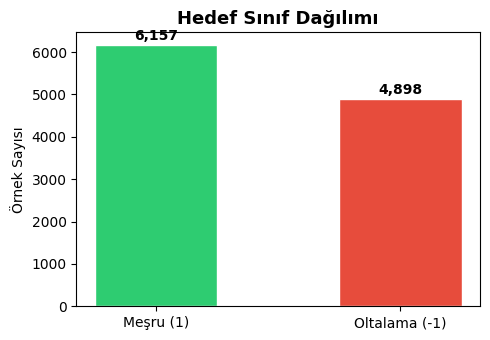

In [ ]:
# Veri setindeki eksik değerlerin sayısını ve hedef sınıf dağılımını kontrol etme
print('Eksik değer sayısı:\n', df.isnull().sum()[df.isnull().sum() > 0])
print('\nSınıf Dağılımı (Result):')
print(df['Result'].value_counts())

# Hedef sınıf dağılımını görselleştirme
fig, ax = plt.subplots(figsize=(5, 3.5))
sinif_renkleri = {'1': '#2ecc71', '-1': '#e74c3c'}
sinif_etiketleri = {'1': 'Meşru (1)', '-1': 'Oltalama (-1)'}
counts = df['Result'].value_counts()
bars = ax.bar([sinif_etiketleri[k] for k in counts.index],
               counts.values,
               color=[sinif_renkleri[k] for k in counts.index],
               edgecolor='white', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Hedef Sınıf Dağılımı', fontsize=13, fontweight='bold')
ax.set_ylabel('Örnek Sayısı')
plt.tight_layout()
plt.show()

# Korelasyon Matrisi ve Özellik İlişkilerinin Analizi

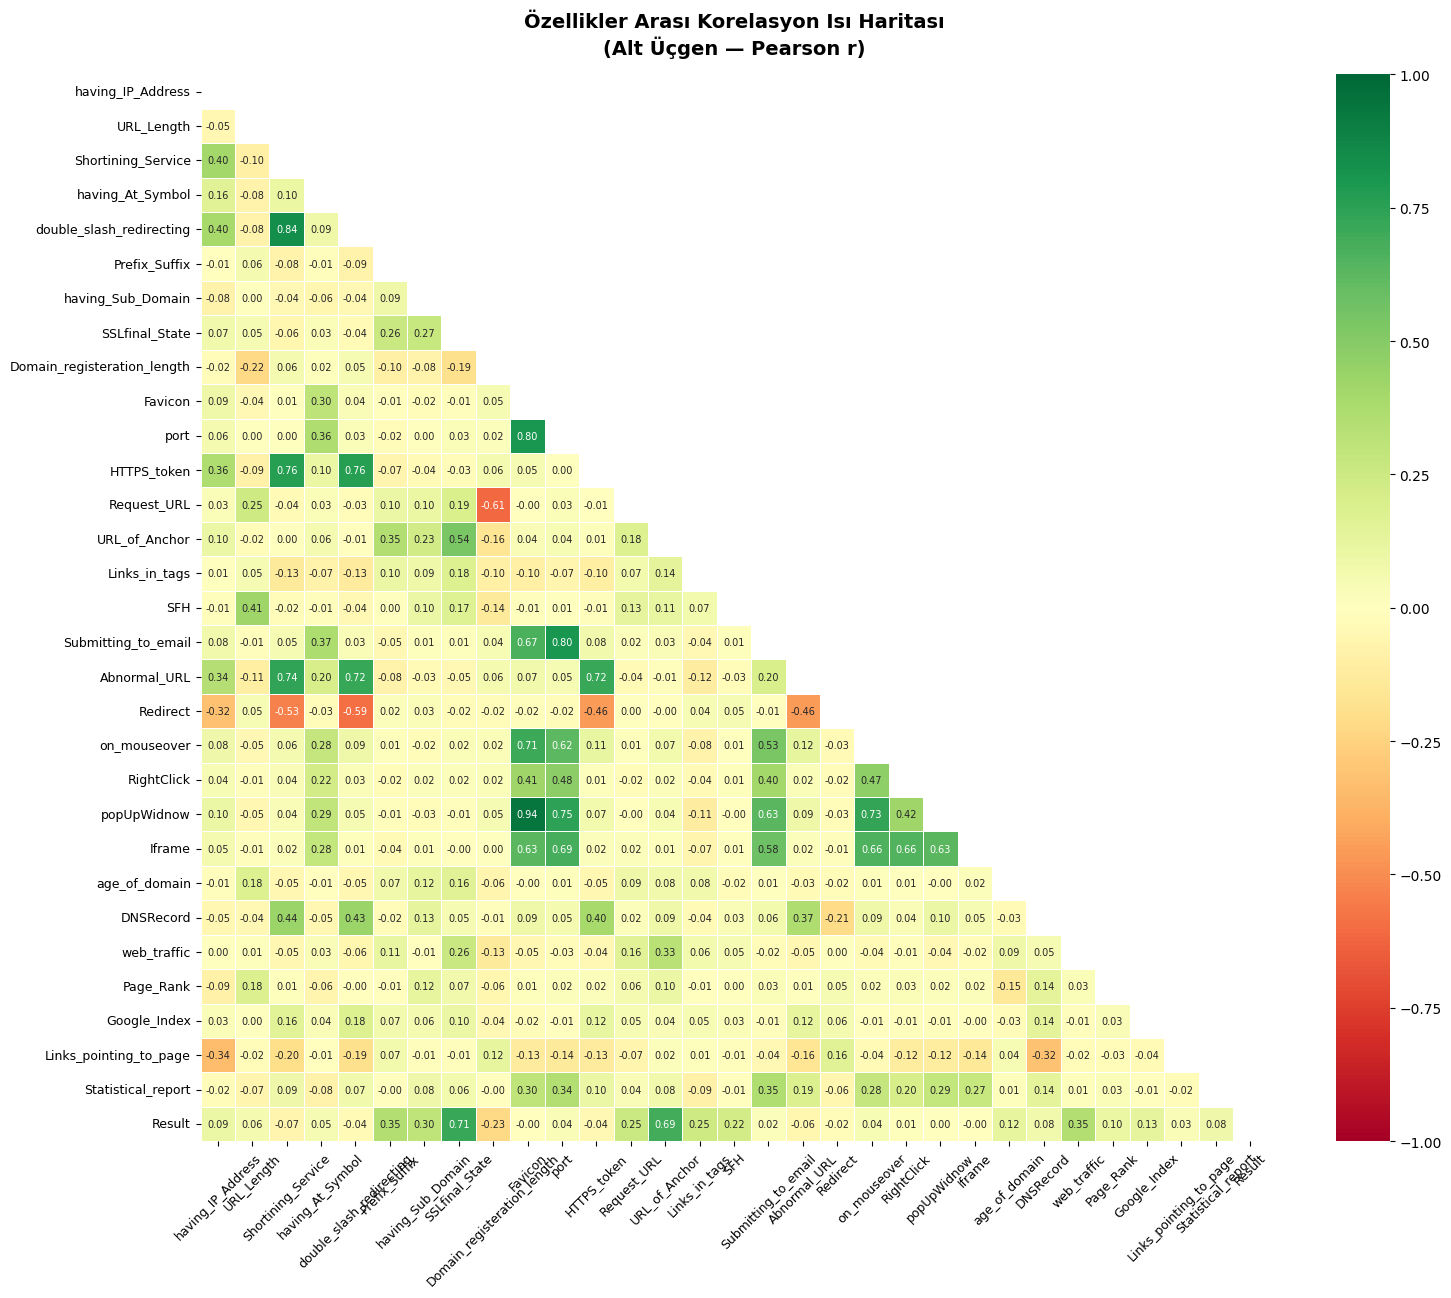


🎯 Hedef (Result) ile En Yüksek Korelasyonlu Özellikler:
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
Domain_registeration_length    0.225789
SFH                            0.221419
Google_Index                   0.128950


In [ ]:
corr_matrix = df.corr() # Korelasyon matrisi oluşturma 

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Üst üçgeni gizle

# Korelasyon matrisi ısı haritası
heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 7},
    ax=ax,
    square=True
)


ax.set_title('Özellikler Arası Korelasyon Isı Haritası\n(Alt Üçgen — Pearson r)', 
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

# Hedef değişkenle en yüksek korelasyonlu özellikler
print('\n🎯 Hedef (Result) ile En Yüksek Korelasyonlu Özellikler:')
print(corr_matrix['Result'].drop('Result').abs().sort_values(ascending=False).head(10).to_string())

# Verinin Özellik(X) ve Hedef Değişkenlerinin(y) Ayrılması

In [ ]:
# 'Result' sütunu haricindeki her şey modelin öğreneceği özelliklerdir (X)
X = df.drop('Result', axis=1)

# Tahmin etmeye çalıştığımız hedef sütun (y)
y = df['Result']

# Verinin Eğitim ve Test Olarak Ayrılması

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42,shuffle=True,stratify=y)

print(f'Eğitim seti: {X_train.shape[0]:,} | Test seti: {X_test.shape[0]:,}')

Eğitim seti: 9,949 | Test seti: 1,106


# Logistic Regression Modelinin Tanımlanması ve Tahmin Sonuçlarına Göre Başarısının Değerlendirilmesi

In [ ]:
# 1. Lojistik Regresyon Modelini Tanımlama ve Eğitme
log_reg_modeli = LogisticRegression(max_iter=1000, random_state=42)
log_reg_modeli.fit(X_train, y_train)

# 2. Test Verisi Üzerinde Tahmin Yapma
y_pred_log = log_reg_modeli.predict(X_test)

# 3. Başarı Değerlendirmesi
dogruluk_orani_log = accuracy_score(y_test, y_pred_log)
# F1-Skorunu hesaplama satırını buraya ekliyoruz:
f1_skoru_log = f1_score(y_test, y_pred_log, average='macro')

# 4. Sonuçları Ekrana Yazdırma
print("="*50)
print("       LOJİSTİK REGRESYON PERFORMANSI      ")
print("="*50)
print(f"Doğruluk Oranı (Accuracy) : %{dogruluk_orani_log * 100:.2f}")
print(f"F1-Skoru  : %{f1_skoru_log * 100:.2f}\n")
print("-" * 50)

print("--- Sınıflandırma Raporu (Classification Report) ---")
print(classification_report(y_test, y_pred_log))

print("--- Karmaşıklık Matrisi (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_log))

       LOJİSTİK REGRESYON PERFORMANSI      
Doğruluk Oranı (Accuracy) : %92.77
F1-Skoru  : %92.65

--------------------------------------------------
--- Sınıflandırma Raporu (Classification Report) ---
              precision    recall  f1-score   support

          -1       0.93      0.91      0.92       490
           1       0.93      0.94      0.94       616

    accuracy                           0.93      1106
   macro avg       0.93      0.93      0.93      1106
weighted avg       0.93      0.93      0.93      1106

--- Karmaşıklık Matrisi (Confusion Matrix) ---
[[444  46]
 [ 34 582]]


# Logistic Regression İçin GridSearch 

In [ ]:
# 1. Lojistik Regresyon için denenecek hiperparametreler
log_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],          # Düzenlileştirme (Regularization) gücü. (Küçük değerler daha güçlü ceza verir)
    'penalty': ['l1', 'l2'],               # Hata hesaplama ve ceza yöntemi
    'solver': ['liblinear', 'saga']        # Optimizasyon algoritmaları (Hem l1 hem l2'yi destekleyenler seçildi)
}

# 2. Temel modeli tanımlama (Yakınsama uyarısı almamak için max_iter yüksek tutuldu)
log_temel = LogisticRegression(max_iter=2000, random_state=42)

# 3. GridSearchCV nesnesini oluşturma (5 Katlı Çapraz Doğrulama ile)
log_grid_search = GridSearchCV(estimator=log_temel, param_grid=log_param_grid, 
                               cv=5, n_jobs=-1, verbose=1, scoring='f1_macro')

# 4. Modeli eğitme ve en iyi parametreleri arama
print("Lojistik Regresyon için Grid Search başlatılıyor...\n")
log_grid_search.fit(X_train, y_train)

# 5. Sonuçları yazdırma
print("\n--- Grid Search Tamamlandı ---")
print(f"En İyi Parametreler: {log_grid_search.best_params_}")
print(f"En İyi Çapraz Doğrulama Skoru: %{log_grid_search.best_score_ * 100:.2f}")

Lojistik Regresyon için Grid Search başlatılıyor...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- Grid Search Tamamlandı ---
En İyi Parametreler: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
En İyi Çapraz Doğrulama Skoru: %92.73


# Logistic Regression İçin En İyi Modelin Kaydedilmesi

In [ ]:
# 1. Grid Search'ün bulduğu en iyi modeli bir değişkene alma
en_iyi_log_model = log_grid_search.best_estimator_

# 2. Bu en iyi model ile test seti (X_test) üzerinde TAHMİN yapma
y_pred = en_iyi_log_model.predict(X_test)

# 3. Nihai başarıyı F1 Skoru ile ölçme
# Veri setindeki sınıfların (örn: -1 ve 1) dengeli ölçülmesi için average='macro' kullanmak sağlıklıdır.
nihai_f1_skoru = f1_score(y_test, y_pred, average='macro')
print(f"Optimize Edilmiş Lojistik Regresyon Test F1 Skoru: %{nihai_f1_skoru * 100:.2f}\n")

# Opsiyonel: Eğer Accuracy skorunu da görmek istersen alt satırda onu da yazdırabilirsin:
nihai_log_skoru = en_iyi_log_model.score(X_test, y_test)
print(f"Optimize Edilmiş Lojistik Regresyon Test Doğruluğu (Accuracy): %{nihai_log_skoru * 100:.2f}\n")

# 4. Modeli ileride kullanmak üzere .pkl formatında kaydetme
joblib.dump(en_iyi_log_model, 'en_iyi_lojistik_regresyon_modeli.pkl')
print("✅ Model başarıyla 'en_iyi_lojistik_regresyon_modeli.pkl' adıyla kaydedildi!")

Optimize Edilmiş Lojistik Regresyon Test F1 Skoru: %92.19

Optimize Edilmiş Lojistik Regresyon Test Doğruluğu (Accuracy): %92.31

✅ Model başarıyla 'en_iyi_lojistik_regresyon_modeli.pkl' adıyla kaydedildi!


# SVM Modelinin Tanımlanması ve Tahmin Sonuçlarına Göre Değerlendirilmesi

In [ ]:
# 1. Temel SVM Modelini Tanımlama
# SVC (Support Vector Classifier), sınıflandırma problemleri için kullanılan SVM türüdür.
svm_modeli = SVC(random_state=42)

# 2. Modeli Eğitme
svm_modeli.fit(X_train, y_train)

# 3. Test Verisi Üzerinde Tahmin Yapma
y_pred_svm = svm_modeli.predict(X_test)

# 4. Başarı Değerlendirmesi
dogruluk_orani_svm = accuracy_score(y_test, y_pred_svm)
# F1-Skorunu hesaplama satırını buraya ekliyoruz:
f1_skoru_svm = f1_score(y_test, y_pred_svm, average='macro')

# 5. Sonuçları Ekrana Yazdırma
print("="*50)
print("             TEMEL SVM PERFORMANSI             ")
print("="*50)
print(f"Doğruluk Oranı (Accuracy) : %{dogruluk_orani_svm * 100:.2f}")
print(f"F1-Skoru (Dengeli Başarı) : %{f1_skoru_svm * 100:.2f}\n")
print("-" * 50)

print("--- Sınıflandırma Raporu (Classification Report) ---")
print(classification_report(y_test, y_pred_svm))

print("--- Karmaşıklık Matrisi (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_svm))

             TEMEL SVM PERFORMANSI             
Doğruluk Oranı (Accuracy) : %94.76
F1-Skoru (Dengeli Başarı) : %94.66

--------------------------------------------------
--- Sınıflandırma Raporu (Classification Report) ---
              precision    recall  f1-score   support

          -1       0.96      0.92      0.94       490
           1       0.94      0.97      0.95       616

    accuracy                           0.95      1106
   macro avg       0.95      0.94      0.95      1106
weighted avg       0.95      0.95      0.95      1106

--- Karmaşıklık Matrisi (Confusion Matrix) ---
[[451  39]
 [ 19 597]]


# SVM Modeli için GridSearch

In [ ]:
# 1. SVM için denenecek hiperparametreler (Izgara)
svm_param_grid = {
    'C': [0.1, 1, 10, 100],               # Hata toleransı (Küçük değerler yumuşak sınır, büyük değerler sert sınır çizer)
    'kernel': ['linear', 'rbf', 'poly'],  # Veriyi ayırmak için kullanılacak uzay dönüşüm fonksiyonları
    'gamma': ['scale', 'auto']            # Etki alanı yarıçapı (Sadece 'rbf' ve 'poly' için geçerlidir)
}

# 2. Temel Modeli Çağırma
svm_temel = SVC(random_state=42)

# 3. GridSearchCV Nesnesini Oluşturma (5 Katlı Çapraz Doğrulama)
# DİKKAT: accuracy yerine f1_macro kullanıldı!
svm_grid_search = GridSearchCV(estimator=svm_temel, param_grid=svm_param_grid, 
                               cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

# 4. Grid Search İşlemini Başlatma
print("SVM için Grid Search başlatılıyor, bu işlem biraz zaman alabilir...\n")
svm_grid_search.fit(X_train, y_train)

# 5. En İyi Sonuçları Yazdırma
print("\n" + "="*50)
print("--- SVM Grid Search Tamamlandı ---")
print("="*50)
print(f"En İyi Parametreler: {svm_grid_search.best_params_}")
print(f"En İyi Çapraz Doğrulama Skoru (F1): %{svm_grid_search.best_score_ * 100:.2f}")
print("-" * 50)

SVM için Grid Search başlatılıyor, bu işlem biraz zaman alabilir...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

--- SVM Grid Search Tamamlandı ---
En İyi Parametreler: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
En İyi Çapraz Doğrulama Skoru (F1): %96.38
--------------------------------------------------


# SVM Algoritması İçin En İyi Modelin Test Edilmesi ve Kaydedilmesi

In [ ]:
# 1. Grid Search'ün bulduğu en iyi modeli bir değişkene alma
en_iyi_svm_model = svm_grid_search.best_estimator_

# 2. Bu en iyi model ile test seti (X_test) üzerinde TAHMİN yapma
y_pred_svm = en_iyi_svm_model.predict(X_test)

# 3. Nihai başarıyı F1 Skoru ile ölçme
# Veri setindeki sınıfların (örn: -1 ve 1) dengeli ölçülmesi için average='macro' kullanmak sağlıklıdır.
nihai_f1_skoru_svm = f1_score(y_test, y_pred_svm, average='macro')
print(f"Optimize Edilmiş SVM Test F1 Skoru: %{nihai_f1_skoru_svm * 100:.2f}\n")

# Opsiyonel: Eğer Accuracy skorunu da görmek istersen alt satırda onu da yazdırabilirsin:
nihai_svm_skoru = en_iyi_svm_model.score(X_test, y_test)
print(f"Optimize Edilmiş SVM Test Doğruluğu (Accuracy): %{nihai_svm_skoru * 100:.2f}\n")

# 4. Modeli ileride kullanmak üzere .pkl formatında kaydetme
joblib.dump(en_iyi_svm_model, 'en_iyi_svm_modeli.pkl')
print("✅ Model başarıyla 'en_iyi_svm_modeli.pkl' adıyla kaydedildi!")

Optimize Edilmiş SVM Test F1 Skoru: %97.34

Optimize Edilmiş SVM Test Doğruluğu (Accuracy): %97.38

✅ Model başarıyla 'en_iyi_svm_modeli.pkl' adıyla kaydedildi!


# KNN Modelinin Tanımlanması ve Tahmin Sonuçlarına Göre Değerlendirilmesi

In [ ]:
# 1. Temel KNN modelini tanımlama (Sınıflandırma için en yakın 5 komşuya bakılacak)
knn_modeli = KNeighborsClassifier(n_neighbors=5)

# 2. Modeli ölçeklendirilmiş eğitim verisiyle eğitme (Uzaklık temelli olduğu için ölçeklendirme şart)
knn_modeli.fit(X_train, y_train)

# 3. Ölçeklendirilmiş test verisi üzerinde modelin tahminlerini alma
y_pred_knn = knn_modeli.predict(X_test)

# 4. Modelin test verisi üzerindeki genel doğruluk oranını (Accuracy) ve F1 Skorunu hesaplama
dogruluk_orani_knn = accuracy_score(y_test, y_pred_knn)
f1_skoru_knn = f1_score(y_test, y_pred_knn, average='macro')

print(f"KNN Doğruluk Oranı (Accuracy): %{dogruluk_orani_knn * 100:.2f}")
print(f"KNN F1-Skoru (Dengeli Başarı): %{f1_skoru_knn * 100:.2f}\n")

# 5. Precision, Recall ve F1-Score gibi detaylı sınıflandırma metriklerini yazdırma
print("--- Sınıflandırma Raporu (Classification Report) ---")
print(classification_report(y_test, y_pred_knn))

# 6. Modelin doğru bildiği ve yanıldığı sitelerin sayısını matris tablosu olarak yazdırma
print("--- Karmaşıklık Matrisi (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_knn))

KNN Doğruluk Oranı (Accuracy): %94.21
KNN F1-Skoru (Dengeli Başarı): %94.13

--- Sınıflandırma Raporu (Classification Report) ---
              precision    recall  f1-score   support

          -1       0.94      0.93      0.93       490
           1       0.94      0.95      0.95       616

    accuracy                           0.94      1106
   macro avg       0.94      0.94      0.94      1106
weighted avg       0.94      0.94      0.94      1106

--- Karmaşıklık Matrisi (Confusion Matrix) ---
[[455  35]
 [ 29 587]]


# KNN — Optimal k Grafiği

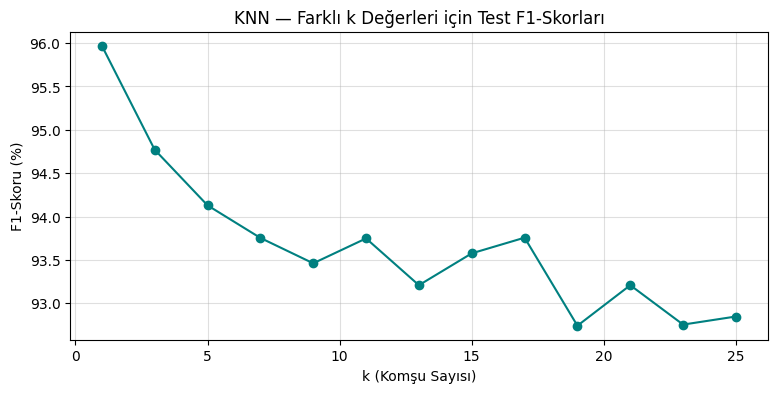

In [ ]:
# KNN için farklı k değerlerinde F1-Skorlarını hesaplama ve görselleştirme
k_f1_skorlar = []
k_araligi = range(1, 26, 2) # 1'den 25'e kadar sadece tek sayıları deniyoruz (eşitliği bozmak için)

for k in k_araligi:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    
    # Modelin test verisi üzerindeki tahminlerini alma
    y_pred_k = knn_k.predict(X_test)
    
    # Accuracy yerine F1-Skorunu (Dengeli Başarı) hesaplıyoruz
    f1 = f1_score(y_test, y_pred_k, average='macro')
    k_f1_skorlar.append(f1)

# Grafiği Çizdirme
plt.figure(figsize=(9, 4))
plt.plot(list(k_araligi), [f * 100 for f in k_f1_skorlar], marker='o', color='teal')
plt.xlabel('k (Komşu Sayısı)')
plt.ylabel('F1-Skoru (%)')
plt.title('KNN — Farklı k Değerleri için Test F1-Skorları')
plt.grid(True, alpha=0.4)
plt.show()

# KNN Algoritması için GridSearch

In [ ]:
# 1. KNN için denenecek hiperparametre havuzu (K-değerleri, ağırlıklar ve uzaklık ölçümleri)
knn_param_grid = {
    'n_neighbors': list(range(3, 22, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
# 2. Temel KNN modelini çağırıyoruz
knn_temel = KNeighborsClassifier()
# 3. GridSearchCV nesnesini oluşturma (5 Katlı Çapraz Doğrulama ile)
# Modeli, belirlediğimiz havuzdaki tüm kombinasyonlar için eğitecek ve en iyisini seçecek
knn_grid_search = GridSearchCV(estimator=knn_temel, param_grid=knn_param_grid,
                               cv=5, n_jobs=-1, verbose=1, scoring='f1_macro')

# 4. Modeli ölçeklendirilmiş veri ile eğitmeye ve parametre aramaya başlama
print("KNN için Grid Search başlatılıyor...\n")
knn_grid_search.fit(X_train, y_train)

# 5. Bulunan en iyi parametreleri ve o parametrelerin çapraz doğrulama skorunu yazdırma
print("\n--- Grid Search Tamamlandı ---")
print(f"En İyi Parametreler: {knn_grid_search.best_params_}")
print(f"En İyi Çapraz Doğrulama Skoru (F1): %{knn_grid_search.best_score_ * 100:.2f}")

KNN için Grid Search başlatılıyor...

Fitting 5 folds for each of 60 candidates, totalling 300 fits

--- Grid Search Tamamlandı ---
En İyi Parametreler: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
En İyi Çapraz Doğrulama Skoru (F1): %96.47


# KNN Algoritması için En iyi Parametrelerin Test Edilmesi ve Kaydedilmesi

In [ ]:
# 1. Grid Search'ün bulduğu en iyi modeli bir değişkene alma
en_iyi_knn_modeli = knn_grid_search.best_estimator_


y_pred_knn = en_iyi_knn_modeli.predict(X_test)

# Sınıf dengesizliğine karşı macro average ile F1 hesaplama
nihai_f1_skoru_knn = f1_score(y_test, y_pred_knn, average='macro')
print(f"Optimize Edilmiş KNN Test F1 Skoru: %{nihai_f1_skoru_knn * 100:.2f}")
# -----------------------------------

# 2. Bu en iyi modelin test seti üzerindeki nihai başarısını ölçme (Accuracy)
nihai_knn_skoru = en_iyi_knn_modeli.score(X_test, y_test)
print(f"Optimize Edilmiş KNN Test Doğruluğu: %{nihai_knn_skoru * 100:.2f}\n")

# 3. Modeli ileride projelerinde kullanmak üzere bilgisayara kaydetme

joblib.dump(en_iyi_knn_modeli, 'en_iyi_knn_modeli.pkl')

print("✅ Model başarıyla 'en_iyi_knn_modeli.pkl' adıyla kaydedildi!")

Optimize Edilmiş KNN Test F1 Skoru: %96.14
Optimize Edilmiş KNN Test Doğruluğu: %96.20

✅ Model başarıyla 'en_iyi_knn_modeli.pkl' adıyla kaydedildi!


# Karar Ağacı Modelinin Tanımlanması ve Tahmin Sonuçlarına Göre Başarısının Değerlendirilmesi

In [ ]:
# 1. Temel Karar Ağacı (Decision Tree) modelini tanımlama
# random_state=42: Kod her çalıştığında ağacın aynı kurallarla bölünmesini (sonuçların tutarlı olmasını) sağlar.
kararAgac_modeli = DecisionTreeClassifier(random_state=42)

# 2. Modeli eğitim verisiyle eğitme (Öğrenme ve dallanma aşaması)
# Karar ağaçları uzaklık hesabı yapmadığı için veriyi ölçeklendirmeden (ham X_train ile) kullanıyoruz.
kararAgac_modeli.fit(X_train, y_train)

# 3. Eğitilmiş model ile test verisi (X_test) üzerinde tahminler üretme
y_pred = kararAgac_modeli.predict(X_test)

# 4. Modelin genel başarısını (Doğruluk/Accuracy) ve F1 Skorunu hesaplama ve ekrana yazdırma
dogruluk_orani = accuracy_score(y_test, y_pred)
f1_skoru = f1_score(y_test, y_pred, average='macro')

print(f"Modelin Doğruluk Oranı (Accuracy): %{dogruluk_orani * 100:.2f}")
print(f"Modelin F1-Skoru (Dengeli Başarı) : %{f1_skoru * 100:.2f}\n")

# 5. Sınıf bazında (Güvenli ve Oltalama) Precision, Recall ve F1-Score gibi detaylı metrikleri yazdırma
print("Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_test, y_pred))

# 6. Modelin doğru bildiği ve yanlış sınıflandırdığı sitelerin sayısal tablosunu yazdırma
print("Karmaşıklık Matrisi (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))

Modelin Doğruluk Oranı (Accuracy): %96.56
Modelin F1-Skoru (Dengeli Başarı) : %96.52

Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

          -1       0.96      0.96      0.96       490
           1       0.97      0.97      0.97       616

    accuracy                           0.97      1106
   macro avg       0.97      0.97      0.97      1106
weighted avg       0.97      0.97      0.97      1106

Karmaşıklık Matrisi (Confusion Matrix):
[[472  18]
 [ 20 596]]


# Karar Ağacı Modeli için Özellik Önemini Çıkarma ve Görselleştirme

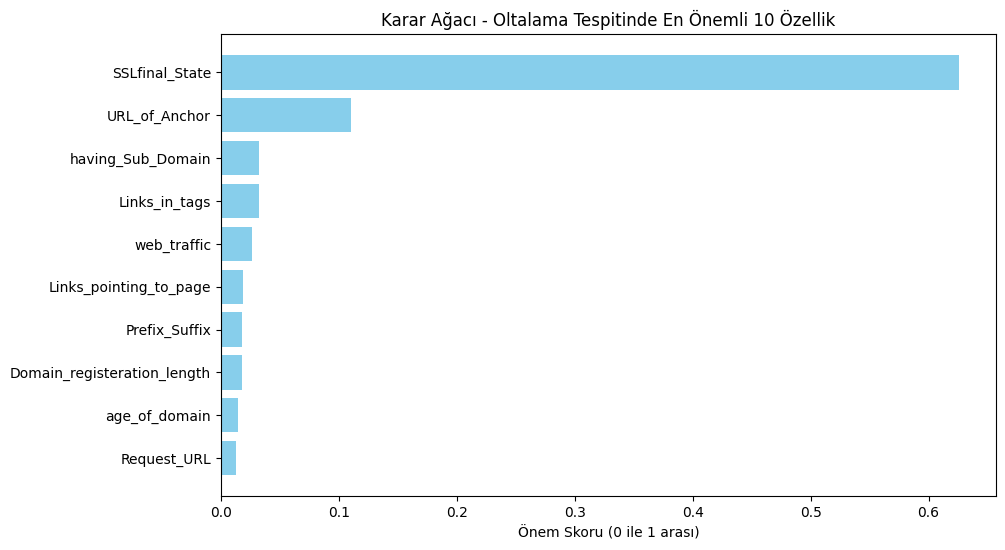

              Özellik  Önem Skoru
7      SSLfinal_State    0.625765
13      URL_of_Anchor    0.110278
6   having_Sub_Domain    0.032550
14      Links_in_tags    0.032544
25        web_traffic    0.026230


In [ ]:
# Özellik önemlerini modelden çekip bir DataFrame'e dönüştürme
onem_skorlari = pd.DataFrame({
    'Özellik': X_train.columns,
    'Önem Skoru': kararAgac_modeli.feature_importances_
})

# Önem derecesine göre büyükten küçüğe sıralama
onem_skorlari = onem_skorlari.sort_values(by='Önem Skoru', ascending=False)

# Sadece ilk 10 en önemli özelliği görselleştirme
plt.figure(figsize=(10, 6))
plt.barh(onem_skorlari['Özellik'][:10], onem_skorlari['Önem Skoru'][:10], color='skyblue')
plt.gca().invert_yaxis() # En önemli özellik en üstte görünsün
plt.title('Karar Ağacı - Oltalama Tespitinde En Önemli 10 Özellik')
plt.xlabel('Önem Skoru (0 ile 1 arası)')
plt.show()

# En önemli 5 özelliği terminale yazdırma
print(onem_skorlari.head(5))

# 

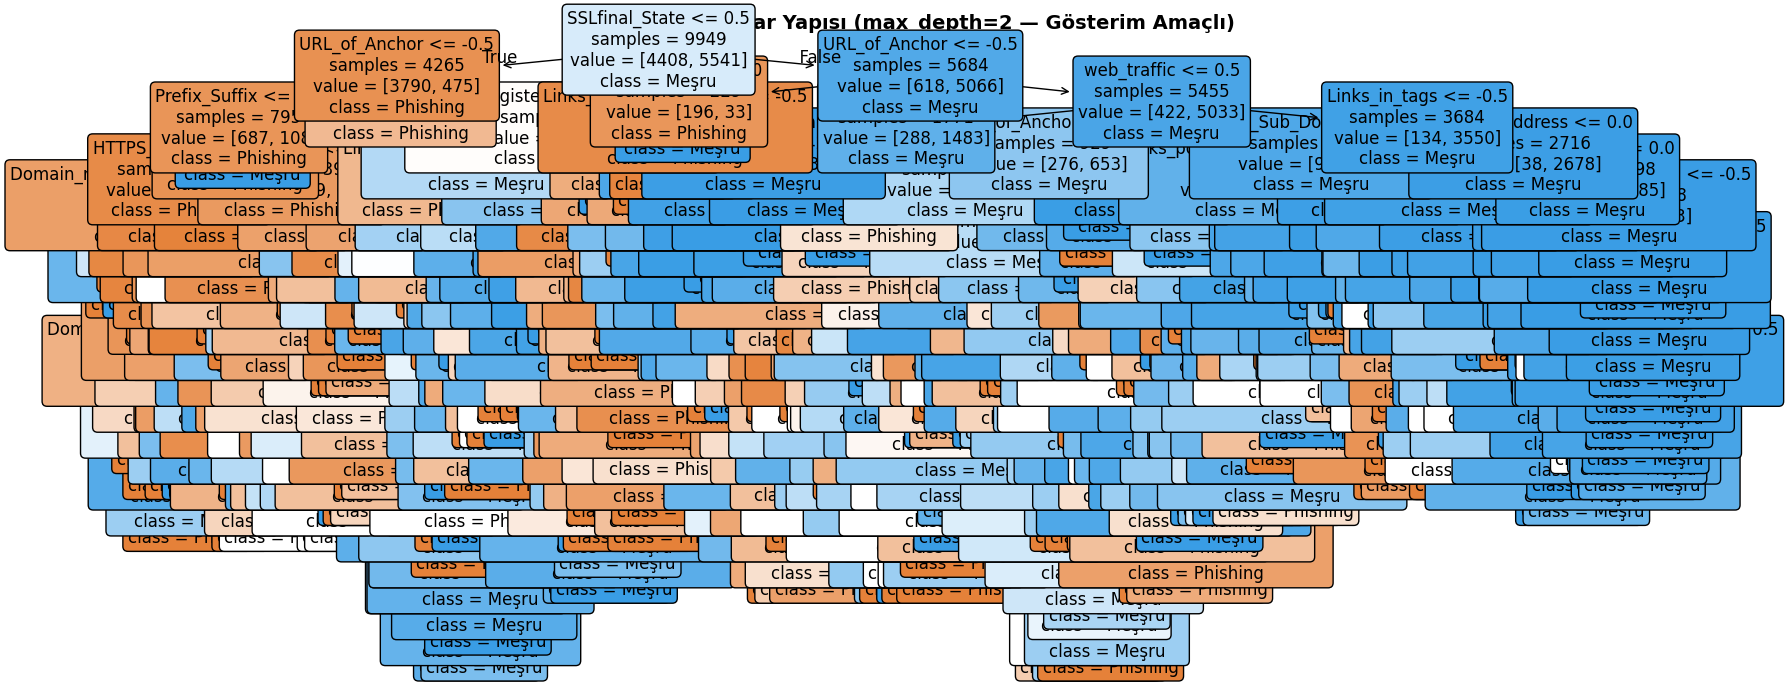

In [ ]:
plt.figure(figsize=(18, 7))
plot_tree(
    kararAgac_modeli,
    feature_names=X_train.columns.tolist(),
    class_names=['Phishing', 'Meşru'],
    filled=True,
    rounded=True,
    fontsize=12,
    impurity=False,      # Gini değerini gizle, temiz görünsün
    proportion=False
)
plt.title('Karar Ağacı Karar Yapısı (max_depth=2 — Gösterim Amaçlı)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Karar Ağacı Modeli için GridSearch

In [ ]:
# 1. Karar Ağacı için denenecek hiperparametreler (Izgara)
dt_param_grid = {
    'max_depth': [None, 10, 20, 30, 50],     # Ağacın inebileceği maksimum derinlik (Aşırı öğrenmeyi engeller)
    'min_samples_split': [2, 5, 10, 20],     # Bir düğümün (node) bölünebilmesi için gereken minimum örnek sayısı
    'criterion': ['gini', 'entropy']         # Bölünme kalitesini ölçen matematiksel fonksiyonlar
}

# 2. Temel Modeli Tanımlama
dt_temel = DecisionTreeClassifier(random_state=42)

# 3. GridSearchCV Nesnesini Oluşturma (5 Katlı Çapraz Doğrulama)
# DİKKAT: Siber güvenlik hedefimize uygun olarak f1_macro kullanıldı!
dt_grid_search = GridSearchCV(estimator=dt_temel, param_grid=dt_param_grid, 
                              cv=5, n_jobs=-1, verbose=1, scoring='f1_macro')

# 4. Grid Search İşlemini Başlatma
print("Karar Ağacı için Grid Search başlatılıyor...\n")
dt_grid_search.fit(X_train, y_train)

# 5. En İyi Sonuçları Yazdırma
print("\n" + "="*50)
print("--- Karar Ağacı Grid Search Tamamlandı ---")
print("="*50)
print(f"En İyi Parametreler: {dt_grid_search.best_params_}")
print(f"En İyi Çapraz Doğrulama Skoru (F1): %{dt_grid_search.best_score_ * 100:.2f}")
print("-" * 50)

Karar Ağacı için Grid Search başlatılıyor...

Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- Karar Ağacı Grid Search Tamamlandı ---
En İyi Parametreler: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
En İyi Çapraz Doğrulama Skoru (F1): %96.17
--------------------------------------------------


# Karar Ağacı Algoritması için En iyi Parametrelerin Test Edilmesi ve Kaydedilmesi

In [ ]:
# 1. Grid Search'ün bulduğu en iyi modeli bir değişkene alma
en_iyi_dt_modeli = dt_grid_search.best_estimator_

# 2. Test seti üzerinde tahmin yapma
y_pred_dt = en_iyi_dt_modeli.predict(X_test)

# 3. Nihai başarıyı F1 Skoru ile ölçme (Dengeli macro average)
nihai_f1_skoru_dt = f1_score(y_test, y_pred_dt, average='macro')
print(f"\nOptimize Edilmiş Karar Ağacı Test F1 Skoru: %{nihai_f1_skoru_dt * 100:.2f}")

#4. Doğruluk (Accuracy) skorunu yazdırma
nihai_dt_skoru = en_iyi_dt_modeli.score(X_test, y_test)
print(f"Optimize Edilmiş Karar Ağacı Test Doğruluğu (Accuracy): %{nihai_dt_skoru * 100:.2f}\n")

# 5. Modeli ileride kullanmak üzere kaydetme
joblib.dump(en_iyi_dt_modeli, 'en_iyi_karar_agaci_modeli.pkl')
print("✅ Model başarıyla 'en_iyi_karar_agaci_modeli.pkl' adıyla kaydedildi!")


Optimize Edilmiş Karar Ağacı Test F1 Skoru: %96.52
Optimize Edilmiş Karar Ağacı Test Doğruluğu (Accuracy): %96.56

✅ Model başarıyla 'en_iyi_karar_agaci_modeli.pkl' adıyla kaydedildi!


# RandomForest Modelini Oluşturma ve Tahmin Değerlerine Göre Başarı Değerlendirmesi 

In [ ]:
# 1. Random Forest modelini tanımlama (n_estimators=100: 100 adet karar ağacı kullanılacak)
rf_modeli = RandomForestClassifier(n_estimators=100, random_state=42)

# Modeli ham eğitim verisiyle eğitme
rf_modeli.fit(X_train, y_train)

# 2. Eğitilmiş model ile ham test verisi (X_test) üzerinde tahminler üretme
y_pred_rf = rf_modeli.predict(X_test)

# 3. Modelin genel test başarısını (Doğruluk/Accuracy) ve F1 Skorunu hesaplama
dogruluk_orani_rf = accuracy_score(y_test, y_pred_rf)
f1_skoru_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f"Random Forest Doğruluk Oranı (Accuracy): %{dogruluk_orani_rf * 100:.2f}")
print(f"Random Forest F1-Skoru (Dengeli Başarı) : %{f1_skoru_rf * 100:.2f}\n")

# 4. Sınıfların (Güvenli/Oltalama) ayrı ayrı Precision, Recall ve F1 skorlarını yazdırma
print("Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_test, y_pred_rf))

# 5. Modelin kaç siteyi doğru, kaçını yanlış sınıflandırdığını gösteren hata matrisi
print("Karmaşıklık Matrisi (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Doğruluk Oranı (Accuracy): %97.47
Random Forest F1-Skoru (Dengeli Başarı) : %97.43

Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

          -1       0.97      0.97      0.97       490
           1       0.98      0.98      0.98       616

    accuracy                           0.97      1106
   macro avg       0.97      0.97      0.97      1106
weighted avg       0.97      0.97      0.97      1106

Karmaşıklık Matrisi (Confusion Matrix):
[[475  15]
 [ 13 603]]


# Random Forest için Özellik Önemini Çıkarma ve Görselleştirme

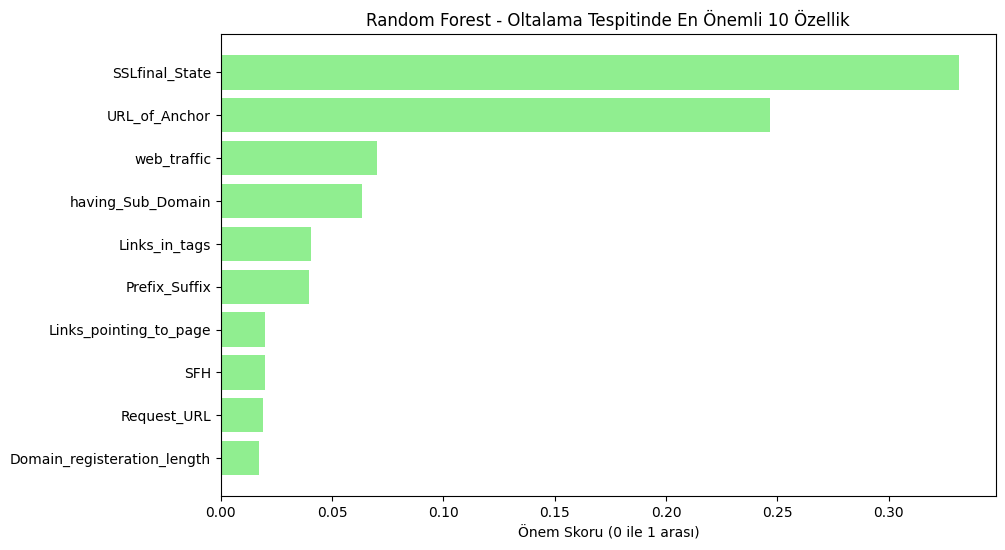

Random Forest - En Önemli 5 Özellik:
              Özellik  Önem Skoru
7      SSLfinal_State    0.331522
13      URL_of_Anchor    0.246708
25        web_traffic    0.069918
6   having_Sub_Domain    0.063561
14      Links_in_tags    0.040594


In [ ]:
# Random Forest modelindeki özellik önem skorlarını çekip bir DataFrame'e dönüştürme
onem_skorlari_rf = pd.DataFrame({
    'Özellik': X_train.columns,
    'Önem Skoru': rf_modeli.feature_importances_
}).sort_values(by='Önem Skoru', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(onem_skorlari_rf['Özellik'][:10], onem_skorlari_rf['Önem Skoru'][:10], color='lightgreen')
plt.gca().invert_yaxis()
plt.title('Random Forest - Oltalama Tespitinde En Önemli 10 Özellik')
plt.xlabel('Önem Skoru (0 ile 1 arası)')
plt.show()

print("Random Forest - En Önemli 5 Özellik:")
print(onem_skorlari_rf.head(5))

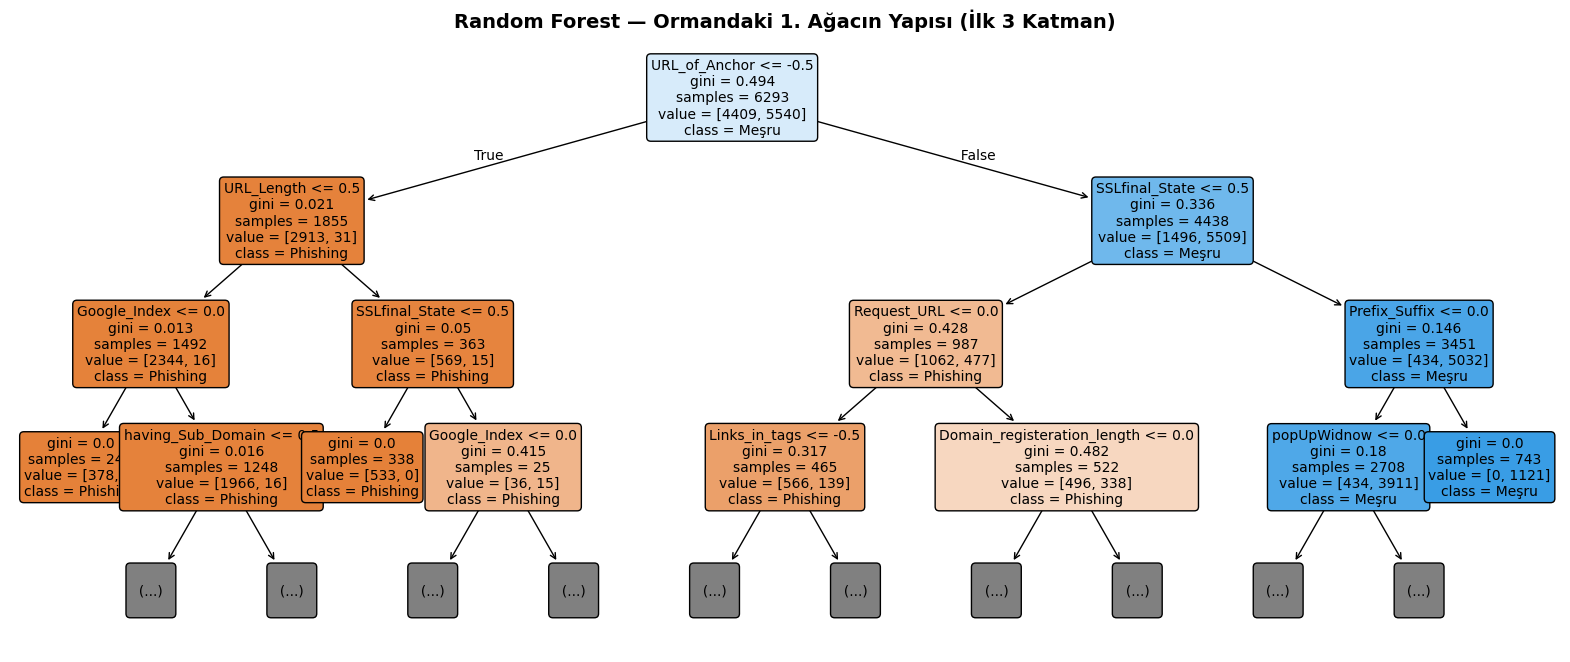

In [ ]:
plt.figure(figsize=(20, 8))
plot_tree(
    rf_modeli.estimators_[0],   # Ormandaki ilk ağacı seçiyoruz
    feature_names=X_train.columns.tolist(),
    class_names=['Phishing', 'Meşru'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title("Random Forest — Ormandaki 1. Ağacın Yapısı (İlk 3 Katman)", fontsize=14, fontweight='bold')
plt.show()

# RandomForest Modeli İçin GridSearch

In [ ]:
# 1. Denenmesini istediğimiz parametrelerin bir sözlüğünü (grid) oluşturuyoruz
param_grid = {
    'n_estimators': [50, 100, 200],         # Ağaç sayısı
    'max_depth': [None, 10, 20, 30],        # Ağaçların inebileceği maksimum derinlik
    'min_samples_split': [2, 5, 10],        # Bir düğümün bölünmesi için gereken minimum örnek sayısı
    'criterion': ['gini', 'entropy']        # Bilgi kazancı hesaplama yöntemi
}

# 2. Temel modelimizi çağırıyoruz
rf_temel = RandomForestClassifier(random_state=42)

# 3. GridSearchCV nesnesini oluşturuyoruz
# cv=5 : 5 Katlı Çapraz Doğrulama (K-Fold CV) yapılacağını belirtir
# n_jobs=-1 : İşlemi hızlandırmak için bilgisayarın tüm işlemci çekirdeklerini kullanır

grid_search = GridSearchCV(estimator=rf_temel, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

# 4. Grid Search işlemini başlatıyoruz (Eğitim verisi üzerinde)
print("Random Forest için Grid Search başlatılıyor, bu işlem birkaç dakika sürebilir...\n")
grid_search.fit(X_train, y_train)

# 5. En iyi sonuçları ekrana yazdırma
print("\n" + "="*50)
print("--- Random Forest Grid Search Tamamlandı ---")
print("="*50)
print(f"En İyi Parametreler: {grid_search.best_params_}")
print(f"En İyi Çapraz Doğrulama Skoru (F1): %{grid_search.best_score_ * 100:.2f}")
print("-" * 50)

Random Forest için Grid Search başlatılıyor, bu işlem birkaç dakika sürebilir...

Fitting 5 folds for each of 72 candidates, totalling 360 fits

--- Random Forest Grid Search Tamamlandı ---
En İyi Parametreler: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 100}
En İyi Çapraz Doğrulama Skoru (F1): %97.14
--------------------------------------------------


# En İyi Parametreli RandomForest Modelinin Test Edilmesi ve Kaydedilmesi

In [ ]:
# 1. Grid Search'ün bulduğu en iyi modeli bir değişkene alma
en_iyi_rf_modeli = grid_search.best_estimator_

# 2. Bu en iyi model ile test seti (X_test) üzerinde TAHMİN yapma
y_pred_rf_opt = en_iyi_rf_modeli.predict(X_test)

# 3. Nihai başarıyı F1 Skoru ile ölçme (Sınıf dengesizliğine karşı macro average)
nihai_f1_skoru_rf = f1_score(y_test, y_pred_rf_opt, average='macro')
print(f"\nOptimize Edilmiş Random Forest Test F1 Skoru: %{nihai_f1_skoru_rf * 100:.2f}")

# 4. Accuracy skorunu yazdırma
nihai_rf_skoru = en_iyi_rf_modeli.score(X_test, y_test)
print(f"Optimize Edilmiş Random Forest Test Doğruluğu (Accuracy): %{nihai_rf_skoru * 100:.2f}\n")

# 5. Modeli ileride projelerinde kullanmak üzere bilgisayara kaydetme
joblib.dump(en_iyi_rf_modeli, 'en_iyi_random_forest_modeli.pkl')
print("✅ Model başarıyla 'en_iyi_random_forest_modeli.pkl' adıyla kaydedildi!")


Optimize Edilmiş Random Forest Test F1 Skoru: %97.34
Optimize Edilmiş Random Forest Test Doğruluğu (Accuracy): %97.38

✅ Model başarıyla 'en_iyi_random_forest_modeli.pkl' adıyla kaydedildi!


# Yapay Sinir Ağları (ANN) için RandomizedSearchCV ile Hiperparametre Optimizasyonu

In [ ]:
# 1. Denenecek parametrelerin 'havuzunu' oluşturuyoruz
ann_param_havuzu = {
    # Tek katmanlı 50/100 nöron veya Çift katmanlı (50, 25) nöron mimarileri
    'hidden_layer_sizes': [(50,), (100,), (50, 25)], 
    
    # Nöronların ateşlenme mantığı (Derin öğrenmenin klasikleri)
    'activation': ['relu', 'tanh'],                  
    
    # Optimizasyon algoritması (Adam genelde en hızlısı ve en iyisidir)
    'solver': ['adam', 'sgd'],                       
    
    # Öğrenme katsayısı adaptif mi olsun sabit mi?
    'learning_rate': ['constant', 'adaptive'],
    
    # Aşırı öğrenmeyi (Overfitting) engellemek için ceza katsayısı
    'alpha': [0.0001, 0.001, 0.01]                   
}

# 2. Temel ANN (MLP) modelini çağırıyoruz
# max_iter=2000: Model öğrenmeden pes etmesin diye limiti yüksek tutuyoruz
ann_temel = MLPClassifier(max_iter=2000, random_state=42)

# 3. RandomizedSearchCV nesnesini oluşturuyoruz
# n_iter=10: Sadece 10 farklı rastgele kombinasyon dene
random_search = RandomizedSearchCV(estimator=ann_temel, param_distributions=ann_param_havuzu, 
                                   n_iter=10, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='f1_macro')

# 4. Arama işlemini başlatıyoruz
print("Yapay Sinir Ağı için Akıllı Arama (RandomizedSearch) başlatılıyor...\n")
random_search.fit(X_train, y_train)

# 5. Sonuçları yazdırma
print("\n" + "="*50)
print("--- Yapay Sinir Ağı Arama Tamamlandı ---")
print("="*50)
print(f"En İyi Parametreler: {random_search.best_params_}")
# Buradaki skor, eğitim sırasındaki en iyi Çapraz Doğrulama F1 skorudur
print(f"En İyi Çapraz Doğrulama F1 Skoru: %{random_search.best_score_ * 100:.2f}")
print("-" * 50)


Yapay Sinir Ağı için Akıllı Arama (RandomizedSearch) başlatılıyor...

Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- Yapay Sinir Ağı Arama Tamamlandı ---
En İyi Parametreler: {'solver': 'adam', 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100,), 'alpha': 0.001, 'activation': 'tanh'}
En İyi Çapraz Doğrulama F1 Skoru: %96.79
--------------------------------------------------


# Bulunan En İyi ANN Modelini Test Etme ve Kaydetme

In [ ]:
# RandomizedSearch'ün bulduğu en iyi modeli bir değişkene alma
en_iyi_ann_model = random_search.best_estimator_
# Bu en iyi model ile test seti üzerinde tahmin yapma
y_pred_ann = en_iyi_ann_model.predict(X_test)

# F1 skorunu (macro average) hesaplıyoruz
# Siber güvenlik standartlarımıza uygun olarak iki sınıfı da dengeli ölçüyoruz.
nihai_f1_ann = f1_score(y_test, y_pred_ann, average='macro')
# En iyi modelin test seti üzerindeki genel doğruluğunu ölçme
nihai_ann_skoru = en_iyi_ann_model.score(X_test, y_test)

# Sonuçları yazdırma
print(f"Optimize Edilmiş ANN Test F1 Skoru: %{nihai_f1_ann * 100:.2f}")
print(f"Optimize Edilmiş ANN Test Doğruluğu (Accuracy): %{nihai_ann_skoru * 100:.2f}")

# Modeli kaydetme
joblib.dump(en_iyi_ann_model, 'en_iyi_ann_modeli.pkl')
print("\n✅ Model başarıyla 'en_iyi_ann_modeli.pkl' adıyla kaydedildi!")

Optimize Edilmiş ANN Test F1 Skoru: %97.07
Optimize Edilmiş ANN Test Doğruluğu (Accuracy): %97.11

✅ Model başarıyla 'en_iyi_ann_modeli.pkl' adıyla kaydedildi!


# Yapay Sinir Ağı Öğrenme Eğrisi

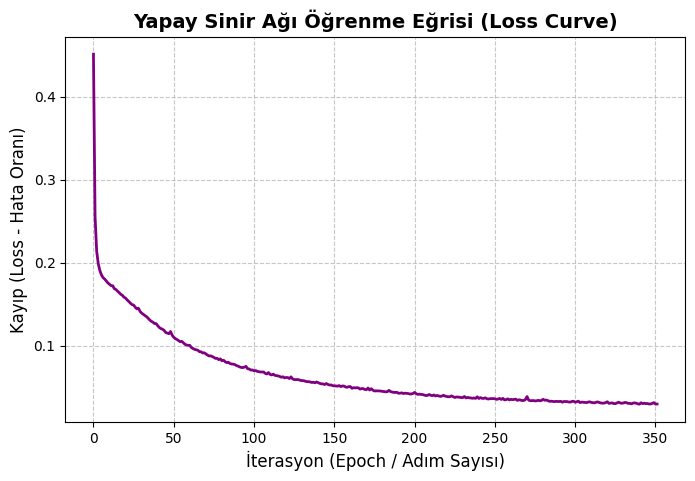

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(en_iyi_ann_model.loss_curve_, color='purple', linewidth=2)
plt.title('Yapay Sinir Ağı Öğrenme Eğrisi (Loss Curve)', fontsize=14, fontweight='bold')
plt.xlabel('İterasyon (Epoch / Adım Sayısı)', fontsize=12)
plt.ylabel('Kayıp (Loss - Hata Oranı)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# XGBoost Modelini Oluşturma ve Tahmin Değerlerine Göre Başarı Değerlendirmesi 

In [ ]:
# 1. ÖNCE X'leri integer'a çeviriyoruz
X_train_xgb = X_train.astype(int)
X_test_xgb  = X_test.astype(int)


# Bu sayede metin olan "1"ler sayı olan 1'e dönüşür ve eşleşme doğru çalışır.
y_train_xgb = (y_train.astype(int) == 1).astype(int)
y_test_xgb  = (y_test.astype(int) == 1).astype(int)

print("1 çalıştı - Etiketler güvenle dönüştürüldü.")


print("\nTest Seti Sınıf Dağılımı:")
print(pd.Series(y_test_xgb).value_counts())

# 3. Temel XGBoost modeli
xgb_modeli = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_modeli.fit(X_train_xgb, y_train_xgb)

print("2 çalıştı - Model eğitildi.")

# 4. Tahmin ve Metrikler
y_pred_xgb = xgb_modeli.predict(X_test_xgb)
dogruluk_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
f1_xgb = f1_score(y_test_xgb, y_pred_xgb, average='macro')

print("3 çalıştı - Tahminler alındı.\n")

print(f"XGBoost Doğruluk: %{dogruluk_xgb*100:.2f}")
print(f"XGBoost F1-Skoru: %{f1_xgb*100:.2f}")
print("\n--- XGBoost Sınıflandırma Raporu ---")
print(classification_report(y_test_xgb, y_pred_xgb))

1 çalıştı - Etiketler güvenle dönüştürüldü.

Test Seti Sınıf Dağılımı:
Result
1    616
0    490
Name: count, dtype: int64
2 çalıştı - Model eğitildi.
3 çalıştı - Tahminler alındı.

XGBoost Doğruluk: %97.47
XGBoost F1-Skoru: %97.43

--- XGBoost Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       490
           1       0.97      0.98      0.98       616

    accuracy                           0.97      1106
   macro avg       0.97      0.97      0.97      1106
weighted avg       0.97      0.97      0.97      1106



# XGBOOST Algoritması İçin GridSearch

In [ ]:

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'),
                        xgb_param_grid, cv=5, n_jobs=-1, 
                        verbose=1, scoring='f1_macro')
xgb_grid.fit(X_train_xgb, y_train_xgb)

print(f"En İyi Parametreler: {xgb_grid.best_params_}")
print(f"En İyi CV F1 Skoru: %{xgb_grid.best_score_*100:.2f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
En İyi Parametreler: {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
En İyi CV F1 Skoru: %97.04


# En iyi XGBoost Modeli Test Etme ve Kaydetme 

In [ ]:

en_iyi_xgb = xgb_grid.best_estimator_
y_pred_xgb_opt = en_iyi_xgb.predict(X_test_xgb)

nihai_xgb_acc = accuracy_score(y_test_xgb, y_pred_xgb_opt)
nihai_xgb_f1  = f1_score(y_test_xgb, y_pred_xgb_opt, average='macro')

print(f"Optimize XGBoost Doğruluk: %{nihai_xgb_acc*100:.2f}")
print(f"Optimize XGBoost F1-Skoru: %{nihai_xgb_f1*100:.2f}")

joblib.dump(en_iyi_xgb, 'en_iyi_xgboost_modeli.pkl')
print("✅ Model kaydedildi!")

Optimize XGBoost Doğruluk: %97.74
Optimize XGBoost F1-Skoru: %97.71
✅ Model kaydedildi!


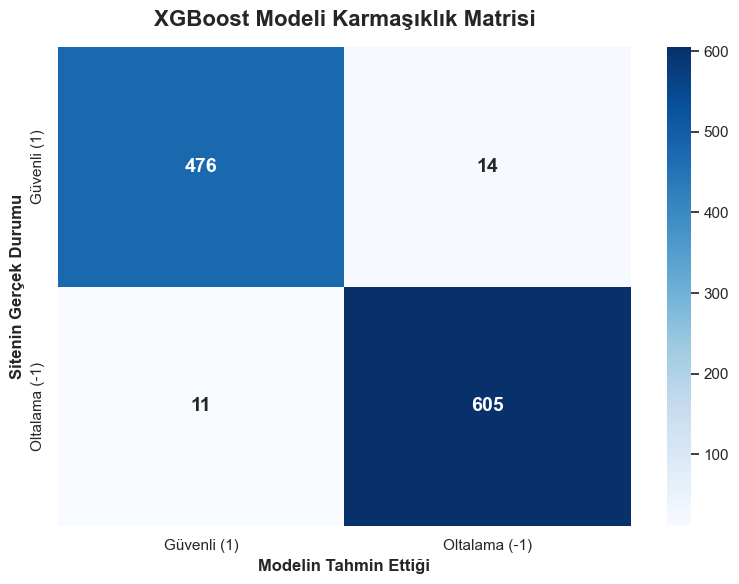

In [ ]:
# 1. Matris değerlerini hesaplama
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb_opt)

# 2. Görselleştirme (Seaborn Isı Haritası)
plt.figure(figsize=(8, 6))

# fmt='d': Sayıların ondalıklı değil tam sayı (integer) olarak yazılmasını sağlar
# cmap='Blues': Siber güvenlik temasına uygun profesyonel mavi renk paleti
grafik_cm = sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=['Güvenli (1)', 'Oltalama (-1)'], 
                        yticklabels=['Güvenli (1)', 'Oltalama (-1)'],
                        annot_kws={"size": 14, "weight": "bold"}) 

# 3. Başlık ve Eksen Etiketleri
plt.title('XGBoost Modeli Karmaşıklık Matrisi', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Modelin Tahmin Ettiği', fontsize=12, fontweight='bold')
plt.ylabel('Sitenin Gerçek Durumu', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# XGBoost Modeli İçin Özellik Önemi 

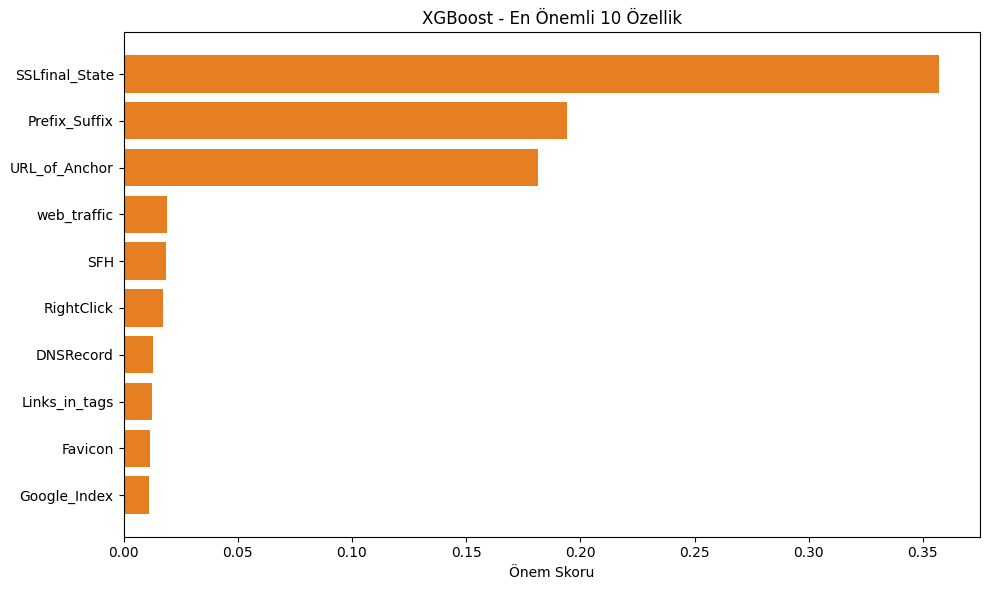

                        Özellik  Önem Skoru
7                SSLfinal_State    0.357153
5                 Prefix_Suffix    0.194108
13                URL_of_Anchor    0.181509
25                  web_traffic    0.018868
15                          SFH    0.018593
20                   RightClick    0.017364
24                    DNSRecord    0.012770
14                Links_in_tags    0.012395
9                       Favicon    0.011404
27                 Google_Index    0.011237
19                 on_mouseover    0.011117
2            Shortining_Service    0.010975
11                  HTTPS_token    0.010957
28       Links_pointing_to_page    0.010814
4      double_slash_redirecting    0.010717
1                    URL_Length    0.009635
6             having_Sub_Domain    0.009514
16          Submitting_to_email    0.009448
22                       Iframe    0.008885
10                         port    0.008318
12                  Request_URL    0.008235
8   Domain_registeration_length 

In [ ]:

onem_xgb = pd.DataFrame({
    'Özellik': X_train_xgb.columns,
    'Önem Skoru': en_iyi_xgb.feature_importances_
}).sort_values('Önem Skoru', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(onem_xgb['Özellik'][:10], onem_xgb['Önem Skoru'][:10], color='#e67e22')
plt.gca().invert_yaxis()
plt.title('XGBoost - En Önemli 10 Özellik')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.show()


print(onem_xgb)

# En iyi Modellere Tahmin Yaptırma

In [ ]:
# 1. Kaydettiğimiz Random Forest modelini içeri aktarıyoruz
rf_model = joblib.load('en_iyi_random_forest_modeli.pkl')

# 2. Tam kolon sırasına göre özel test verimizi (senaryomuzu) oluşturuyoruz
# Değerler: 1 (Güvenli/Legitimate), 0 (Şüpheli/Suspicious), -1 (Oltalama/Phishing)
ozel_veri_senaryosu = {
    'having_IP_Address': [-1],           # -1: URL'de IP adresi kullanılmış
    'URL_Length': [-1],                  # -1: URL çok uzun (54 karakterden fazla)
    'Shortining_Service': [1],           #  1: Kısaltma servisi (bit.ly vb.) kullanılmamış
    'having_At_Symbol': [1],             #  1: URL'de @ sembolü yok
    'double_slash_redirecting': [1],     #  1: Çift slash ile yönlendirme yok
    'Prefix_Suffix': [-1],               # -1: Domain adında tire (-) var
    'having_Sub_Domain': [0],            #  0: Şüpheli miktarda alt alan adı var    
    'SSLfinal_State': [-1],              # -1: SSL sertifikası geçersiz veya sahte (En önemli özellik!)
    'Domain_registeration_length': [-1], # -1: Domain sadece 1 yıllık alınmış
    'Favicon': [1],                      #  1: Favicon kendi domaininden yükleniyor
    'port': [1],                         #  1: Standart portlar açık
    'HTTPS_token': [1],                  #  1: Domain adında "https" kelimesi geçmiyor
    'Request_URL': [-1],                 # -1: Resimler dışarıdan yükleniyor
    'URL_of_Anchor': [-1],               # -1: Linkler bozuk veya dışarı yönlendiriyor (İkinci en önemli özellik)
    'Links_in_tags': [0],                #  0: Meta ve Script etiketleri şüpheli
    'SFH': [-1],                         # -1: Form boşluğa veya dışarı gönderiliyor
    'Submitting_to_email': [1],          #  1: Form verileri maile gönderilmiyor
    'Abnormal_URL': [-1],                # -1: Host adı URL'de yok (Whois anomalisi)
    'Redirect': [1],                     #  1: Sayfa yönlendirmesi normal
    'on_mouseover': [1],                 #  1: Mouse üzerine gelince status bar değişmiyor
    'RightClick': [1],                   #  1: Sağ tık engellenmemiş
    'popUpWidnow': [1],                  #  1: Pop-up penceresinde text alanı yok (Yazım yanlışı verisetiyle aynı bırakıldı)
    'Iframe': [1],                       #  1: Görünmez Iframe kullanılmamış
    'age_of_domain': [-1],               # -1: Domain 6 aydan daha yeni
    'DNSRecord': [-1],                   # -1: DNS kaydı bulunamadı
    'web_traffic': [-1],                 # -1: Sitenin Alexa trafiği yok (Çok yeni/sahte)
    'Page_Rank': [-1],                   # -1: PageRank değeri düşük
    'Google_Index': [1],                 #  1: Sayfa Google tarafından indekslenmiş
    'Links_pointing_to_page': [0],       #  0: Siteye dışarıdan link veren az yer var
    'Statistical_report': [1]            #  1: PhishTank gibi listelerde henüz raporlanmamış
}

# 3. Sözlüğü Pandas DataFrame'e çeviriyoruz
yeni_veri_df = pd.DataFrame(ozel_veri_senaryosu)

# 4. Modeli kullanarak tahmin yapıyoruz
tahmin_sonucu = rf_model.predict(yeni_veri_df)

# 5. Sonucu ekrana yazdırıyoruz
print("--- CANLI TEST SONUCU ---\n")
if tahmin_sonucu[0] == -1:
    print("🚨 DİKKAT: Model bu sitenin OLTALAMA (Phishing) olduğunu tespit etti!")
elif tahmin_sonucu[0] == 1:
    print("✅ GÜVENLİ: Model bu sitenin meşru (Legitimate) bir site olduğunu düşünüyor.")
else:
    print("⚠️ ŞÜPHELİ: Model bu site için kesin bir karar veremedi (Suspicious).")

--- CANLI TEST SONUCU ---

⚠️ ŞÜPHELİ: Model bu site için kesin bir karar veremedi (Suspicious).


In [ ]:
# 1. Kaydettiğimiz Karar Ağacı (Decision Tree) modelini içeri aktarıyoruz
dt_model = joblib.load('en_iyi_karar_agaci_modeli.pkl')

# 2. Tamamen "Güvenli" (Legitimate) bir site senaryosu oluşturuyoruz
# Bu sefer sitemiz banka veya e-devlet gibi çok güvenilir bir siteyi temsil ediyor.
ozel_veri_senaryosu_2 = {
    'having_IP_Address': [1],            # 1: URL'de IP adresi yok, normal domain
    'URL_Length': [1],                   # 1: URL uzunluğu ideal seviyede
    'Shortining_Service': [1],           # 1: Kısaltma servisi kullanılmamış
    'having_At_Symbol': [1],             # 1: URL'de @ sembolü yok
    'double_slash_redirecting': [1],     # 1: Çift slash ile yönlendirme yok
    'Prefix_Suffix': [1],                # 1: Domain adında tire (-) yok
    'having_Sub_Domain': [1],            # 1: Sadece "www" veya yasal alt domain var
    'SSLfinal_State': [1],               # 1: SSL sertifikası çok güvenilir kurumlardan alınmış ve yaşlı!
    'Domain_registeration_length': [1],  # 1: Domain uzun yıllar için tescil edilmiş
    'Favicon': [1],                      # 1: Favicon sitenin kendi içinden yükleniyor
    'port': [1],                         # 1: Sadece olması gereken portlar açık
    'HTTPS_token': [1],                  # 1: Domain içinde şaşırtmacalı "https" kelimesi yok
    'Request_URL': [1],                  # 1: Resimler ve nesneler aynı domainden yükleniyor
    'URL_of_Anchor': [1],                # 1: Sayfa içi linkler sağlam ve kendi sitesine gidiyor
    'Links_in_tags': [1],                # 1: Meta ve script etiketleri temiz
    'SFH': [1],                          # 1: Form verileri aynı domaine (sunucuya) işleniyor
    'Submitting_to_email': [1],          # 1: Mail atma fonksiyonu ile veri çalınmıyor
    'Abnormal_URL': [1],                 # 1: URL ve WHOIS kayıtları eşleşiyor
    'Redirect': [1],                     # 1: Yönlendirme limiti aşılmamış
    'on_mouseover': [1],                 # 1: Javascript ile durum çubuğu gizlenmemiş
    'RightClick': [1],                   # 1: Sağ tık engeli yok
    'popUpWidnow': [1],                  # 1: Veri çalan Pop-up pencereler yok
    'Iframe': [1],                       # 1: Görünmez Iframe kullanılmamış
    'age_of_domain': [1],                # 1: Domain 6 aydan daha yaşlı ve köklü
    'DNSRecord': [1],                    # 1: DNS kayıtları düzgün çalışıyor
    'web_traffic': [1],                  # 1: Alexa'da yüksek trafiğe sahip popüler bir site
    'Page_Rank': [1],                    # 1: PageRank değeri yüksek
    'Google_Index': [1],                 # 1: Google arama sonuçlarında çıkıyor
    'Links_pointing_to_page': [1],       # 1: Siteye dışarıdan link veren çok yer var (Güvenilir)
    'Statistical_report': [1]            # 1: Kara listelerde (PhishTank vb.) adı geçmiyor
}

# 3. Sözlüğü Pandas DataFrame'e çeviriyoruz
yeni_veri_df_2 = pd.DataFrame(ozel_veri_senaryosu_2)

# 4. Karar Ağacı modelimizi kullanarak tahmin yapıyoruz
tahmin_sonucu_2 = dt_model.predict(yeni_veri_df_2)
kesin_sonuc2=int(tahmin_sonucu_2[0])
# 5. Sonucu ekrana yazdırıyoruz
print("--- KARAR AĞACI CANLI TEST SONUCU ---\n")
if kesin_sonuc2 == -1:
    print("🚨 DİKKAT: Model bu sitenin OLTALAMA (Phishing) olduğunu tespit etti!")
elif kesin_sonuc2 == 1:
    print("✅ GÜVENLİ: Model bu sitenin meşru (Legitimate) bir site olduğunu düşünüyor.")
else:
    print("⚠️ ŞÜPHELİ: Model bu site için kesin bir karar veremedi (Suspicious).")   

--- KARAR AĞACI CANLI TEST SONUCU ---

✅ GÜVENLİ: Model bu sitenin meşru (Legitimate) bir site olduğunu düşünüyor.


# Modellerin Performans Karşılaştırması ve Genel Değerlendirme

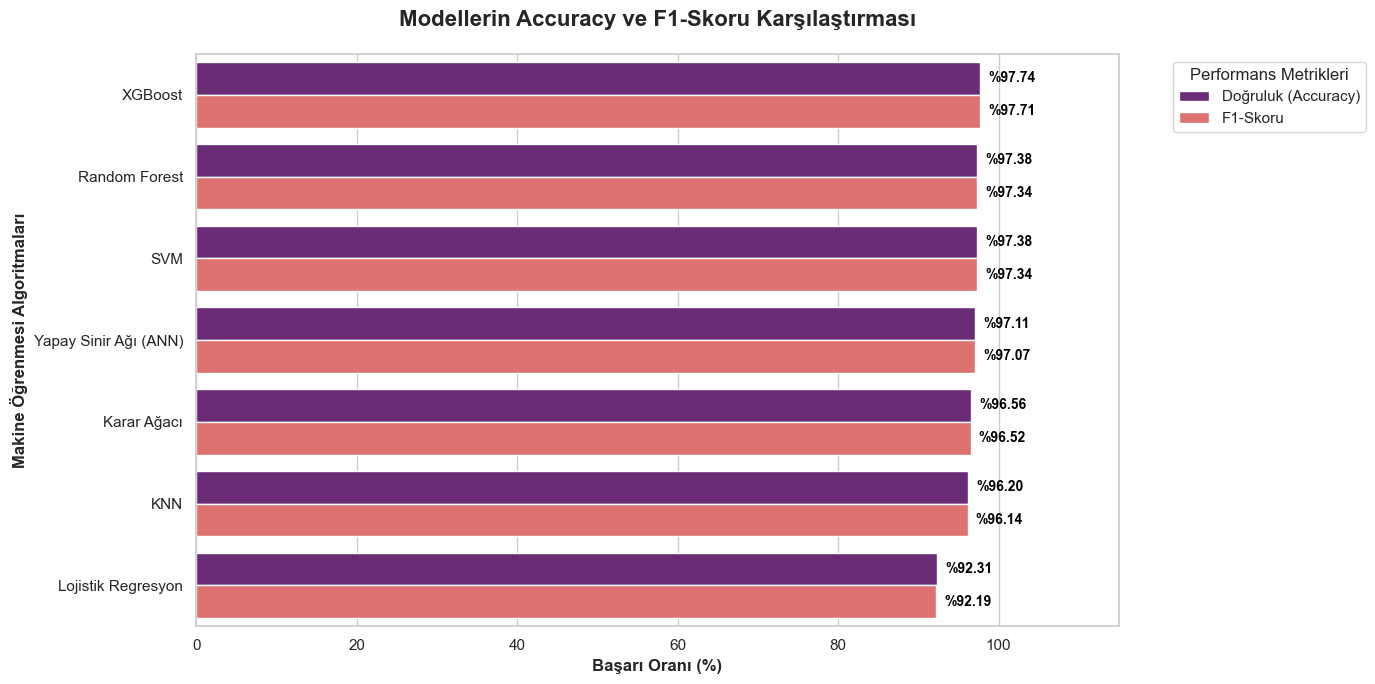


🏆 --- FİNAL MODEL PERFORMANS ANALİZİ --- 🏆

                Model  Doğruluk (Accuracy)  F1-Skoru
              XGBoost            97.739602 97.708427
        Random Forest            97.377939 97.341776
                  SVM            97.377939 97.337079
Yapay Sinir Ağı (ANN)            97.106691 97.067412
          Karar Ağacı            96.564195 96.520458
                  KNN            96.202532 96.144230
   Lojistik Regresyon            92.314647 92.191309


In [ ]:
# 1. Tüm modellerin en iyi (test) Accuracy ve F1 skorlarını topluyoruz
veriler = [
    ['Lojistik Regresyon', nihai_log_skoru * 100, nihai_f1_skoru * 100],
    ['SVM', nihai_svm_skoru * 100, nihai_f1_skoru_svm * 100],
    ['KNN', nihai_knn_skoru * 100, nihai_f1_skoru_knn * 100],
    ['Karar Ağacı', nihai_dt_skoru * 100, nihai_f1_skoru_dt * 100],
    ['Random Forest', nihai_rf_skoru * 100, nihai_f1_skoru_rf * 100],
    ['Yapay Sinir Ağı (ANN)', nihai_ann_skoru * 100, nihai_f1_ann * 100],
    ['XGBoost', nihai_xgb_acc * 100, nihai_xgb_f1 * 100]
]

# 2. Pandas DataFrame oluşturma ve F1 Skoruna göre sıralama
df_karsilastirma = pd.DataFrame(veriler, columns=['Model', 'Doğruluk (Accuracy)', 'F1-Skoru'])
df_karsilastirma = df_karsilastirma.sort_values(by='F1-Skoru', ascending=False)

# 3. Görselleştirme için veriyi "long-form" (uzun) formata getiriyoruz

df_plot = df_karsilastirma.melt(id_vars='Model', var_name='Metrik', value_name='Skor (%)')

# 4. Görselleştirme Aşaması
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")


grafik = sns.barplot(x='Skor (%)', y='Model', hue='Metrik', data=df_plot, palette='magma')

# Çubukların üzerine değerlerini yazdırma
for p in grafik.patches:
    width = p.get_width()
    if width > 0: # Sadece değeri olan çubuklara yazdır
        grafik.text(width + 1, p.get_y() + p.get_height()/2, 
                    f'%{width:.2f}', color='black', va='center', fontsize=10, fontweight='bold')


plt.title('Modellerin Accuracy ve F1-Skoru Karşılaştırması', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Başarı Oranı (%)', fontsize=12, fontweight='bold')
plt.ylabel('Makine Öğrenmesi Algoritmaları', fontsize=12, fontweight='bold')
plt.legend(title='Performans Metrikleri', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 115) 

plt.tight_layout()
plt.show()

# 5. Final Tablo Çıktısı
print("\n🏆 --- FİNAL MODEL PERFORMANS ANALİZİ --- 🏆\n")
print(df_karsilastirma.to_string(index=False))